# data analysis comparison Landat ST, Sentinel-3, ASTER08 and CCI land/lake surface temperatures
This script is the actual analysis script used for the report for the short-term internship with GEUS. It first brings together the lake water/land surface temperature estimates above Kangaarsuup Tasersua (lake_id 6 in How et al. 2025 GrIML dataset), as derived from ASTER08 004, Sentinel 3 LST L2 product, Landsat 4-9 thermal imagery and the CCI global lake dataset. Then, the temperatures are compared using
1. a time series approach (simple plot)
2. A direct comparison of measurements taken during a 3h window, daily mean values or August mean values

After this, the Sentinel-3 analysis is applied to 3 (or depending on how the variable 'selected_lakes' is defined, more lakes can be used) large ice-marginal lakes in Greenland and fits a linear model to explore possible trends per lake. 

In [4]:
# import modules
import pandas as pd
import geopandas as gpd
import numpy as np
import shapely as shp
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import cartopy

### Load pre-processed datasets
Load the lake shoreline from Kangaarsuup Tasersua, as well as pre-processed datasets (done using scripts called `[Sensor/Dataset]_data_preparation` in their respective folders) from ASTER, S3, Landsat and the CCI lake dataset.
Do some renaming of the columns before mergin into one dataframe later to keep track of the column names.

In [5]:
# load lake shoreline 
lake = gpd.read_file('lake_polygons/lake_6_shoreline.geojson')

# the Sentinel S3 LST L2 data
S3 = pd.read_csv("Sentinel_3_LST/data_processed/S3_LST_L2_lake_6.csv")
S3['datetime'] = pd.to_datetime(S3['datetime'])
S3

# the ASTEr data
ASTER08 = pd.read_csv('ASTER08_LSWT/ASTER08_LST_lake_6.csv')
ASTER08['datetime'] = pd.to_datetime(ASTER08["datetime"])

# the CCI lake dataset
CCI = pd.read_csv(r"Copernicus_cci_LSWT_dataset\CCI_LWST_lake6.csv")
CCI['datetime'] = pd.to_datetime(CCI["datetime"])

# the landsat data and set dtypes
LS = pd.read_csv("Landsat4-9/ST_Kangaarsuup_Tasersua.csv", dtype = 
{'LS_ST_max': 'float64', 
'LS_ST_min': 'float64', 
'LS_ST_': 'float64', 
'LS_ST_stddev': 'float64', 
'LS_ST_count': 'int64'
})
LS['date'] = pd.to_datetime(LS.date) # convert alreday given date
LS["datetime"] = pd.to_datetime(LS["system:time_start"],unit="ms") # convert from ns date


In [6]:
# add dataset name to each column to keep track wich col is which after merging
# Add "S3" to all columns except datetime (since this is the column used for matching, so that only one datetime col exists)
S3 = S3.rename(columns={
    col: f"S3_{col}" for col in S3.columns if col != "datetime"
})

ASTER08 = ASTER08.rename(columns={
    col: f"ASTER08_{col}" for col in ASTER08.columns if col != "datetime"
})

# Add "CCI" to all columns except datetime
CCI = CCI.rename(columns={
    col: f"CCI{col}" for col in CCI.columns if col != "datetime"
})

# add LS to all columns 
LS = LS.rename(columns={
    col: f"LS_{col}" for col in LS.columns if col != "datetime"
})



### calculate percentage of lake covered by pixels for each time step
Sometimes, there are only very few pixels valid per scene, and thus the estimate (mean/median etc) is based on very few measurements. To exclude tese values, a measure for the coverage of the lake is calculated as the fraction of pixels present in each scene from the maximum number of pixels ever seen for the lake. Thus, values range from 0 to 1, and later it can be filtered for low coverage. From visual inspection, 45% provided a good measure for filtering, and excluded many extreme values for Sentinel-3. 

In [7]:
#calculate the reliability of the estimate using the number of pixels compared to the max number of pixels
# this can then be used for a threshold the later for quality filtering

# for S3
S3["S3_frac_from_max_pixel_count"] = (S3.S3_n_valid_pixels/S3.S3_n_valid_pixels.max())


# for CCI
CCI["CCI_frac_from_max_pixel_count"] = (CCI.CCIn_valid_pixels/CCI.CCIn_valid_pixels.max())

#landsat: take away the brackets first, then convert str to int, then make calculation
LS["LS_ST_count"] = (
    LS["LS_ST_count"].str.replace("[", "", regex=False).str.replace("]", "", regex=False).str.strip())
LS['LS_ST_count'] = LS['LS_ST_count'].astype(int)
LS['LS_frac_from_max_pixel_count'] = (LS['LS_ST_count']/LS["LS_ST_count"].max())

# for ASTER08
ASTER08['ASTER08_frac_from_max_pixel_count'] = (ASTER08['ASTER08_n_valid_pixels']/ASTER08['ASTER08_n_valid_pixels'].max())


### merge all data into one dataframe for initial plotting:
Use the datetime object to merge the different dataframes. This is an outer join, retaining all data.
However, note that the CCi lake surface waster temperature is only daily values, and I have set the time to 12 midday. Despite merging the CCI data here into the same dataframe, it is not used in the first comparison where only data witin the a 3h window is retained.


In [8]:
# merge all data into one df for initial plotting
combined = ASTER08.merge(
    S3,
    on="datetime",
    how="outer"
).merge(
    CCI,
    on="datetime",
    how="outer"
).merge(
   LS, on = "datetime", how = "outer" )

combined = combined.sort_values("datetime").reset_index(drop=True)
#combined.datetime[combined.CCIlst_mean_C.notna()] # check the time for CCI lake dataset

### filter
For quality control, only temperatures > 12 and >0 are retained. The 0 dgC threshold aims to exclude lake ice, while the 12 degree stem from the observation of maximal temperatures for the ice marginal lakes E and F in figure 6a of Carrea at al. 2025 (https://doi.org/10.5194/tc-19-3139-2025, page 3149). These lakes are located in the South-West of Greenland, can be considered relatively warm, and therefore their warmed recorded mean temperature, taking into account the uncertainty range, has been taken as a conservative maximum temperature threshold. 
There temperature threshold is applied to all datasets (ASTEr, S3, Landsat, CCI). 

Additionally, a threshold of 45% for the minimal coverage of the lake by pixels has been chosen from visual inspection of the scatter when varying the threshold value. The latter threshold are first only applied to S3 and CCI lake dataset, since ASTER and landsat have so few datapoints. 

In [9]:
# filter for positive temperatures MEAN
combined_filter = combined[
    (combined["CCIlst_mean_C"] > 0) |
    (combined["S3_lst_mean_C"] > 0) |
    (combined["LS_ST"] > 0) |
    (combined["ASTER08_lst_mean_C"]>0)
    ]

# filter for maximal temperatures
combined_filter = combined_filter[
    (combined["CCIlst_mean_C"] < 12) |
    (combined["S3_lst_mean_C"] < 12) |
    (combined["LS_ST"]  <12) |
    (combined["ASTER08_lst_mean_C"]<12)
    ]

# filter for positive temperatures MEDIAN
combined_filter = combined_filter[
    (combined["CCIlst_median_C"] > 0) |
    (combined["S3_lst_median_C"] > 0) |
    (combined["LS_ST"] > 0) |
    (combined["ASTER08_lst_median_C"]>0)
    ]

# filter for maximal temperatures
combined_filter = combined_filter[
    (combined["CCIlst_median_C"] < 12) |
    (combined["S3_lst_median_C"] < 12) |
    (combined["LS_ST"]  <12) |
    (combined["ASTER08_lst_median_C"]<12)
    ]

# filter for date range
combined_filter = combined_filter[combined_filter.datetime.between('2016-01-01', '2026-01-01')]

# filter for minimum of 50% of data availability for S3 and CCI: filter out if low coverage <50%
combined_filter = combined_filter[
    (
        combined_filter['S3_frac_from_max_pixel_count'].isna() |
        (combined_filter['S3_frac_from_max_pixel_count'] > 0.45)
    )
    &
    (
        combined_filter['CCI_frac_from_max_pixel_count'].isna() |
        (combined_filter['CCI_frac_from_max_pixel_count'] > 0.45)
    )
]

<positron-console-cell-9>:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
<positron-console-cell-9>:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
<positron-console-cell-9>:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


### Plot time series of all data sets
make a time series plot with all four different data sources for the lake Kangaarsuup Tasersua in South-West Greenland. Note, that for CCI and Sentinel-3 a somewhat stricter filtering has been applied: These are not only filtered for temperature bounds I(0, 12), but also for a minimum coverage of the lake of 45%.  

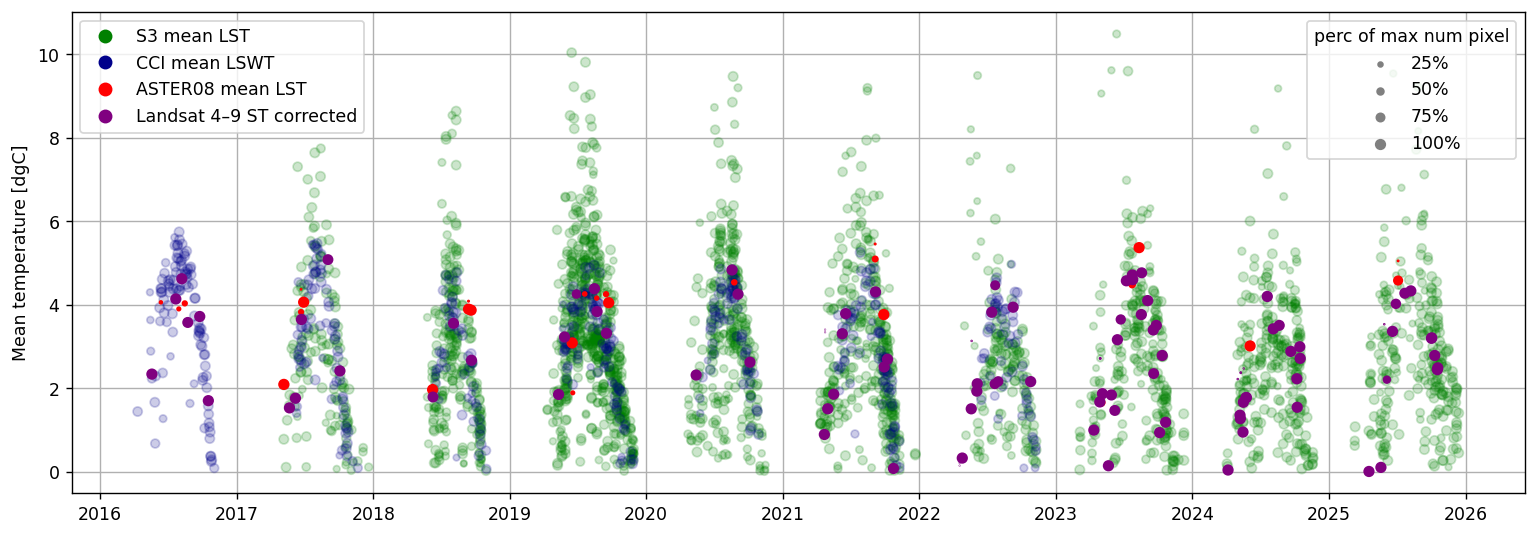

In [10]:
# make an plot with all data
fig, ax = plt.subplots(figsize=(15, 5))

ax.set_axisbelow(True)
ax.grid(True)


#S3 first
ax.scatter(
    x = combined_filter['datetime'], 
    y = combined_filter.S3_lst_mean_C,
    s = combined_filter.S3_frac_from_max_pixel_count*30, 
    marker = "o",
    alpha = 0.2, 
    color = 'green',
    label = "S3 mean LST"
)

#cci lake dataset
ax.scatter(
    x = combined_filter['datetime'], 
    y = combined_filter.CCIlst_mean_C,
    s = combined_filter.CCI_frac_from_max_pixel_count*30,
    marker = "o",
    color = 'darkblue',
    alpha = 0.2, 
    label = "CCI mean LSWT"
)

#ASTER08
ax.scatter(
    x = combined_filter['datetime'], 
    y = combined_filter['ASTER08_lst_mean_C'],
    s = combined_filter.ASTER08_frac_from_max_pixel_count*30, 
     marker = "o",
    color = 'red',
    label = "ASTER08 mean LST"
)

#Landsat4-9
ax.scatter(
    x = combined_filter['datetime'], 
    y = combined_filter['LS_ST'],
    s = combined_filter.LS_frac_from_max_pixel_count*30,
    marker = "o",
    color = 'purple',
    label = "mean Landsat 4-9 ST corrected"
)

#plt.legend()
plt.ylabel('Mean temperature [dgC]')

from matplotlib.lines import Line2D

# Dataset legend
dataset_handles = [
    Line2D([], [], marker='o', linestyle='None',
           color='green', markersize=7, label='S3 mean LST'),
    Line2D([], [], marker='o', linestyle='None',
           color='darkblue', markersize=7, label='CCI mean LSWT'),
    Line2D([], [], marker='o', linestyle='None',
           color='red', markersize=7, label='ASTER08 mean LST'),
    Line2D([], [], marker='o', linestyle='None',
           color='purple', markersize=7, label='Landsat 4–9 ST corrected')
]

# Size legend
size_values = [0.25, 0.5, 0.75, 1.0]

size_handles = [
    ax.scatter([], [], 
               s=value * 30,
               color='gray',
               marker='o',
               label=f'{value:.0%}')
    for value in size_values
]

legend1 = ax.legend(
    handles=dataset_handles,
    loc='upper left'
)

legend2 = ax.legend(
    handles=size_handles,
    loc='upper right',
    title='perc of max num pixel'
)

ax.add_artist(legend1)

# save fig
path = r"plots/timeseries_lake_6.pdf"
plt.savefig(path, format="pdf", bbox_inches="tight")

plt.show()

### Comparsion based on time window
Idea is to match the remotely sensed lake / surface temperature from different sensors based on their aquisition time to enable best comparison.
This can only be done for:
- ASTER08
- Sentinel 3
- Landsat 4-9
Since the CCI lake dataset temporal resolution is only daily.

In the following code sections, one function will be created for making the mathces within a specific time window, and then a function for plotting. 

In [11]:
# define a function for mathcing in a window

import pandas as pd

def time_matches(
    df1,
    df2,
    datetime_col1='datetime',
    datetime_col2='datetime',
    window_hours=3
):
    # Make copies so the original datasets are not modified
    df1 = df1.copy()
    df2 = df2.copy()

    #convert datetime columns to utc
    df1[datetime_col1] = pd.to_datetime(
        df1[datetime_col1], utc=True)
    df2[datetime_col2] = pd.to_datetime(
        df2[datetime_col2], utc=True)

    #rename
    df1 = df1.rename(columns={datetime_col1: 'datetime_1'})
    df2 = df2.rename(columns={datetime_col2: 'datetime_2'})

    ##### create all possible pairs #####
    pairs = df1.merge(
        df2,
        how='cross',
        suffixes=('_1', '_2'))

    #get the abs time difference
    pairs['time_difference'] = (pairs['datetime_1'] - pairs['datetime_2']).abs()

    # get time dif in hours
    pairs['time_difference_hours'] = (
        pairs['time_difference'].dt.total_seconds() / 3600)

    #### do the selection: 3h window 
    matches = pairs[
        pairs['time_difference'] <= pd.Timedelta(hours=window_hours)
    ].copy()

    # sort by time diff
    matches = matches.sort_values(
        'time_difference'
    ).reset_index(drop=True)

    return matches

In [13]:
### make a function for plotting the matched dataframe
def plot_regression(
    x,
    y,
    x_label="X",
    y_label="Y",
    point_color="green",
    regression_color="blue",
    ci_color="blue",
    figsize=(4, 4),
    n_bootstrap=5000,
    seed=42, 
    ylim = None,
    xlim = None
):
    """
    Plot regression of x predictor var and y response var. The scatter plot has:
    - 1:1 line
    - bootstrapped 95% confidence interval
    - r squared
    - slope and intercept
    - RMSE
    - number of observations

    """
    ## convert to np arrays, remove Nas
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)

    x = x[mask]
    y = y[mask]

    # Check that enough data remain
    if len(x) < 2:
        raise ValueError(
            "Not enough valid data points for regression."
        )

    ## actual regression
    m, b = np.polyfit(x, y, 1) # b intercept, m slope

    # make prediction
    y_pred = m * x + b

    # for r square
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2 = 1 - (ss_res / ss_tot)

    # RMSE
    rmse = np.sqrt(
        np.mean((y - y_pred) ** 2))

    ## bootstrapped CI 
    rng = np.random.default_rng(seed)

    x_line = np.linspace(
        x.min(),
        x.max(),
        200)

    bootstrap_predictions = np.empty(
        (n_bootstrap, len(x_line)))

    for i in range(n_bootstrap):

        # Resample observations with replacement
        indices = rng.integers(
            0,
            len(x),
            size=len(x)
        )

        x_boot = x[indices]
        y_boot = y[indices]

        # Regression on bootstrap sample
        m_boot, b_boot = np.polyfit(
            x_boot,
            y_boot,
            1
        )

        # Prediction
        bootstrap_predictions[i] = (
            m_boot * x_line + b_boot
        )

    # 95% CI
    lower_ci = np.percentile(
        bootstrap_predictions,
        2.5,
        axis=0
    )

    upper_ci = np.percentile(
        bootstrap_predictions,
        97.5,
        axis=0
    )

    ##make the plots
    fig, ax = plt.subplots(
        figsize=figsize)

    # scatter plot
    ax.scatter(
        x,
        y,
        alpha=0.5,
        color=point_color,
        edgecolor='none')

    # add the 1:1 line
    min_val = min(
        x.min(),
        y.min())

    max_val = max(
        x.max(),
        y.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="1:1 line")
    
    # add regression line
    ax.plot(
        x_line,
        m * x_line + b,
        color=regression_color,
        linewidth=2,
        label="Regression")

    # 95 CI from the bootstrap

    ax.fill_between(
        x_line,
        lower_ci,
        upper_ci,
        color=ci_color,
        alpha=0.2,
        label="95% CI")

    #labels

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if xlim is not None:
        ax.set_xlim(xlim)
    else:
        ax.set_xlim(min_val, max_val)

    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        ax.set_ylim(min_val, max_val)

    #grid
    ax.grid(
        True,
        linestyle="--",
        alpha=0.4)

    #evaluation metrics and data
    stats_text = (
        f"$R^2$ = {r2:.2f}\n"
        f"Slope = {m:.2f}\n"
        f"Intercept = {b:.2f}\n"
        f"RMSE = {rmse:.2f} °C\n"
        f"n = {len(x)}")

    ax.text(
        0.05,
        0.95,
        stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8))

    # add legends also
    ax.legend(
        loc="lower right")

    plt.tight_layout()

    
    # return also stats
    stats = {
        "slope": m,
        "intercept": b,
        "r2": r2,
        "rmse": rmse,
        "n": len(x)
    }

    return fig, ax, stats

### apply functions for mathcing and plotting 3h window
Here the two functions are now applied. Additonally, we now filter for covarage of ASTER and Landsat scenes too, so the 45% threshold is now also applied.

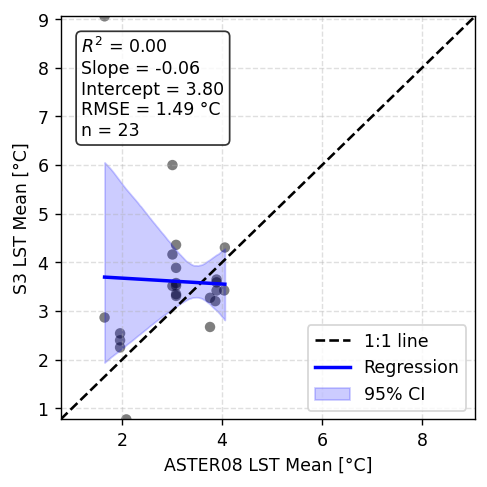

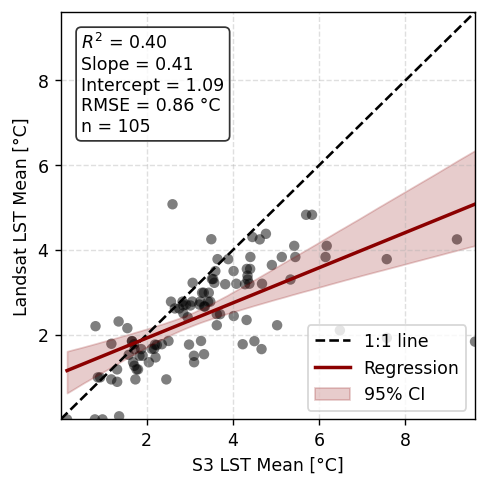

In [14]:
# apply the two functions: 

############ ASTER - S3 #######################
ASTER_S3_matches = time_matches(
    ASTER08,
    S3,
    datetime_col1='datetime',
    datetime_col2='datetime',
    window_hours=3
)

# filter out when low data coverage exists
ASTER_S3_matches = ASTER_S3_matches[
    (
        ASTER_S3_matches['S3_frac_from_max_pixel_count'].isna() |
        (ASTER_S3_matches['S3_frac_from_max_pixel_count'] > 0.45)
    )
    &
    (
        ASTER_S3_matches['ASTER08_frac_from_max_pixel_count'].isna() |
        (ASTER_S3_matches['ASTER08_frac_from_max_pixel_count'] > 0.45)
    )
]

# temperature filtering >0 and <12
ASTER_S3_matches = ASTER_S3_matches[
    (ASTER_S3_matches['ASTER08_lst_mean_C'] > 0) &
    (ASTER_S3_matches['ASTER08_lst_mean_C'] < 12) &
    (ASTER_S3_matches['S3_lst_mean_C'] > 0) &
    (ASTER_S3_matches['S3_lst_mean_C'] < 12)
]



fig, ax, stats = plot_regression(
    x=ASTER_S3_matches['ASTER08_lst_mean_C'],
    y=ASTER_S3_matches['S3_lst_mean_C'],
    x_label="ASTER08 LST Mean [°C]",
    y_label="S3 LST Mean [°C]",
    point_color="black",
    regression_color="blue",
    ci_color="blue", 
    xlim = None, 
    ylim = None
)

path = r"plots/lake_6_3h_scatter_ASTER_S3.pdf"
plt.savefig(path, format="pdf", bbox_inches="tight")



plt.show()

############## ASTEr - Landsat ####################
ASTER_LS_matches = time_matches(
    ASTER08,
    LS,
    datetime_col1='datetime',
    datetime_col2='datetime',
    window_hours=3
)

# filter for minimal coverage of lake
ASTER_LS_matches = ASTER_LS_matches[
    (
        ASTER_LS_matches['LS_frac_from_max_pixel_count'].isna() |
        (ASTER_LS_matches['LS_frac_from_max_pixel_count'] > 0.45)
    )
    &
    (
        ASTER_LS_matches['ASTER08_frac_from_max_pixel_count'].isna() |
        (ASTER_LS_matches['ASTER08_frac_from_max_pixel_count'] > 0.45)
    )
]

#ASTER_LS_matches = ASTER_LS_matches[
#    (ASTER_LS_matches['ASTER08_lst_mean_C'] > 0) &
#    (ASTER_LS_matches['ASTER08_lst_mean_C'] < 12) &
#    (ASTER_LS_matches['LS_ST'] > 0) &
#    (ASTER_LS_matches['LS_ST'] < 12)
#]

#fig, ax, stats = plot_regression(
#    x=ASTER_LS_matches['ASTER08_lst_mean_C'],
##    y=ASTER_LS_matches['LS_ST'],
#    x_label="ASTER08 LST Mean [°C]",
#    y_label="Landsat LST Mean [°C]",
#    point_color="black",
#    regression_color="green",
#    ci_color="green"
#)

#plt.show()

############## S3 - Landsat ########################
S3_LS_matches = time_matches(
    S3,
    LS,
    datetime_col1='datetime',
    datetime_col2='datetime',
    window_hours=3
)

S3_LS_matches = S3_LS_matches[
    (
        S3_LS_matches['S3_frac_from_max_pixel_count'].isna() |
        (S3_LS_matches['S3_frac_from_max_pixel_count'] > 0.45)
    )
    &
    (
        S3_LS_matches['LS_frac_from_max_pixel_count'].isna() |
        (S3_LS_matches['LS_frac_from_max_pixel_count'] > 0.45)
    )
]

S3_LS_matches = S3_LS_matches[
    (S3_LS_matches['S3_lst_mean_C'] > 0) &
    (S3_LS_matches['S3_lst_mean_C'] < 12) &
    (S3_LS_matches['LS_ST'] > 0) &
    (S3_LS_matches['LS_ST'] < 12)
]

fig, ax, stats = plot_regression(
    x=S3_LS_matches['S3_lst_mean_C'],
    y=S3_LS_matches['LS_ST'],
    x_label="S3 LST Mean [°C]",
    y_label="Landsat LST Mean [°C]",
    point_color="black",
    regression_color="darkred",
    ci_color="darkred"
)


# save fig
path = r"plots/lake_6_3h_scatter_S3_LS.pdf"
plt.savefig(path, format="pdf", bbox_inches="tight")

plt.show()

### CCI dataset is daily temporal resolution
Now, the CCI dataset is included. However, this is daily resolution (time set to 12 midday).
Due to the different temporal resolution (not evenly spaced aqisition time for S3 for example (there are often images quite close to each other), although relatively even for Landsat), one cannot simply use the previously created function to match datasets based on the 3h window and enlarge the window to 12h: Sometimes there would be many matches for S3 images, and for other eg images that are more closely together this would result in matching the same s3 image to several Landsat scenes. This would create temporal autocorrelation, which violates the assumption of non-independent errors of the linear model. 

To exclude this effect, I take the daily mean of all data sources to bring it to the same resolution as CCI lake dataset and the match for having daily values. 
However, this creates the difficulty that in some occasions I could be comparing day and night values, both taken at the same calendar day.

Then use the same function as for the 3h comparison for plotting of the daily coparison. 

In [16]:
# note: the combined_filter dataset has already been filtered for all sensors for <0 and >12dgC, and coverage >45% of the lake surface 

# use the previously created data frame (matched by datetime) ## combined
combined_filter["date"] = combined_filter["datetime"].dt.date

# mean daily values
daily_summary = combined_filter.groupby('date', as_index=False).agg({
    'ASTER08_lst_mean_C': 'mean',
    'S3_lst_mean_C': 'mean',
    'CCIlst_mean_C': 'mean', 
    'LS_ST': 'mean'
})

# filter for some values: a type of quality control for S3
# implement upper bounds for S3: below 6dg, or NAN in the column on 

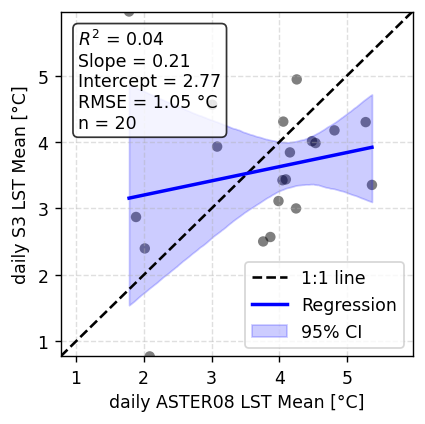

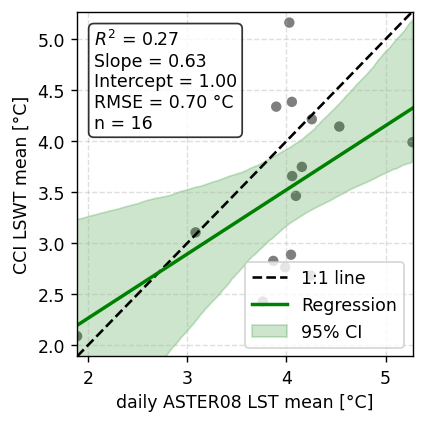

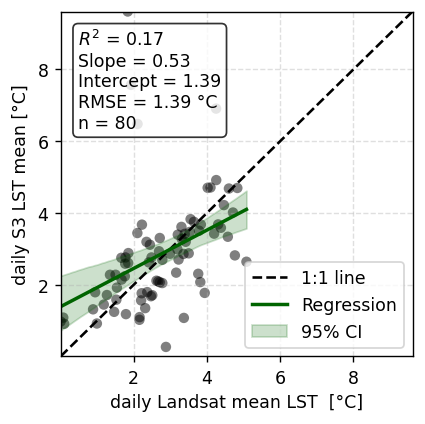

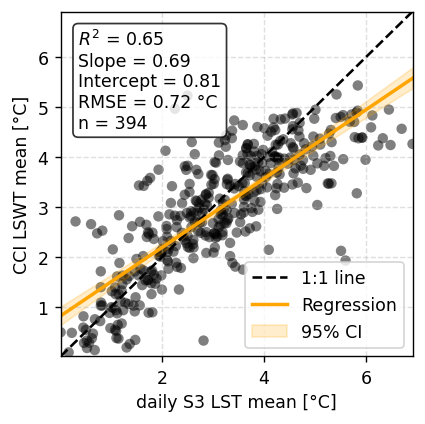

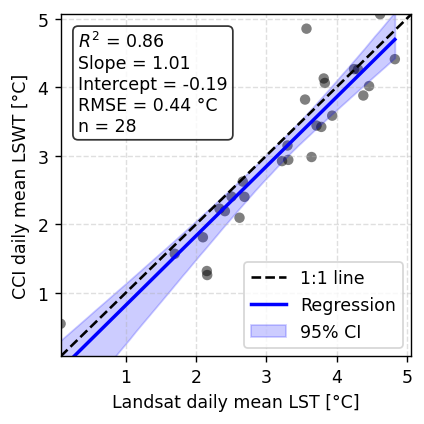

In [17]:
# apply the plotting function to the daily data

############ ASTER - S3 #######################
fig, ax, stats = plot_regression(
    x=daily_summary['ASTER08_lst_mean_C'],
    y=daily_summary['S3_lst_mean_C'],
    x_label="daily ASTER08 LST Mean [°C]",
    y_label="daily S3 LST Mean [°C]",
    point_color="black",
    regression_color="blue",
    ci_color="blue",
    figsize = (3.5,3.5) 
)

path = r"plots/lake_6_daily_scatter_ASTER_LS.pdf"
plt.savefig(path, format="pdf", bbox_inches="tight")

plt.show()

############## ASTEr - Landsat ####################
# Not enough data points for regression #

#fig, ax, stats = plot_regression(
#    x=daily_summary['ASTER08_lst_mean_C'],
#    y=daily_summary['LS_ST'],
#    x_label="daily ASTER08 LST Mean [°C]",
#    y_label="daily Landsat LST Mean [°C]",
#    point_color="black",
#    regression_color="orange",
#    ci_color="yellow"
#)

#plt.show()

############## ASTER - CCI ####################
fig, ax, stats = plot_regression(
    x=daily_summary['ASTER08_lst_mean_C'],
    y=daily_summary['CCIlst_mean_C'],
    x_label="daily ASTER08 LST mean [°C]",
    y_label="CCI LSWT mean [°C]",
    point_color="black",
    regression_color="green",
    ci_color="green", 
    figsize = (3.5,3.5)
)

path = r"plots/lake_6_daily_scatter_ASTER_CCI.pdf"
plt.savefig(path, format="pdf", bbox_inches="tight")

plt.show()



############## S3 - Landsat ########################

fig, ax, stats = plot_regression(
    x=daily_summary['LS_ST'],
    y=daily_summary['S3_lst_mean_C'],
    x_label="daily Landsat mean LST  [°C]",
    y_label="daily S3 LST mean [°C]",
    point_color="black",
    regression_color="darkgreen",
    ci_color="darkgreen", 
    figsize = (3.5,3.5)
)

path = r"plots/lake_6_daily_scatter_S3_LS.pdf"
plt.savefig(path, format="pdf", bbox_inches="tight")

plt.show()

############# S3 vs CCI ############################
fig, ax, stats = plot_regression(
    x=daily_summary['S3_lst_mean_C'],
    y=daily_summary['CCIlst_mean_C'],
    x_label="daily S3 LST mean [°C]",
    y_label="CCI LSWT mean [°C]",
    point_color="black",
    regression_color="orange",
    ci_color="orange", 
    figsize = (3.5,3.5)
)

path = r"plots/lake_6_daily_scatter_S3_CCI.pdf"
plt.savefig(path, format="pdf", bbox_inches="tight")

plt.show()

############# CCI vs Landsat ############################
fig, ax, stats = plot_regression(
    x=daily_summary['LS_ST'],
    y=daily_summary['CCIlst_mean_C'],
    x_label="Landsat daily mean LST [°C]",
    y_label="CCI daily mean LSWT [°C]",
    point_color="black",
    regression_color="blue",
    ci_color="blue", 
    figsize = (3.5,3.5)
)

path = r"plots/lake_6_daily_scatter_CC_LS.pdf"
plt.savefig(path, format="pdf", bbox_inches="tight")

plt.show()

### do a comparison of the august temperature 

in the IML data set Panny only used the August lake temperatures since she could be sure that by then the lake would not be ice-covered anymore.
Therefore, I here compare the mean august temperatures for all the years (seperately) from the different sensors, using box plots. 

Note, that before creating the plot, data is filtered by the ollowing criteria:
- only august temperatures, in order to exclude the possobility that there could be somehow ice on the lake
- look at years from 2016 onward, since before this there is only few landsat (and one ASTEr) scene that could be used, and from 2016 there is the CCI lake dataset available.
- all the other thresholds (temperature bounds I(0, 12) and 45% coverage are used here too)

# do a box plot 



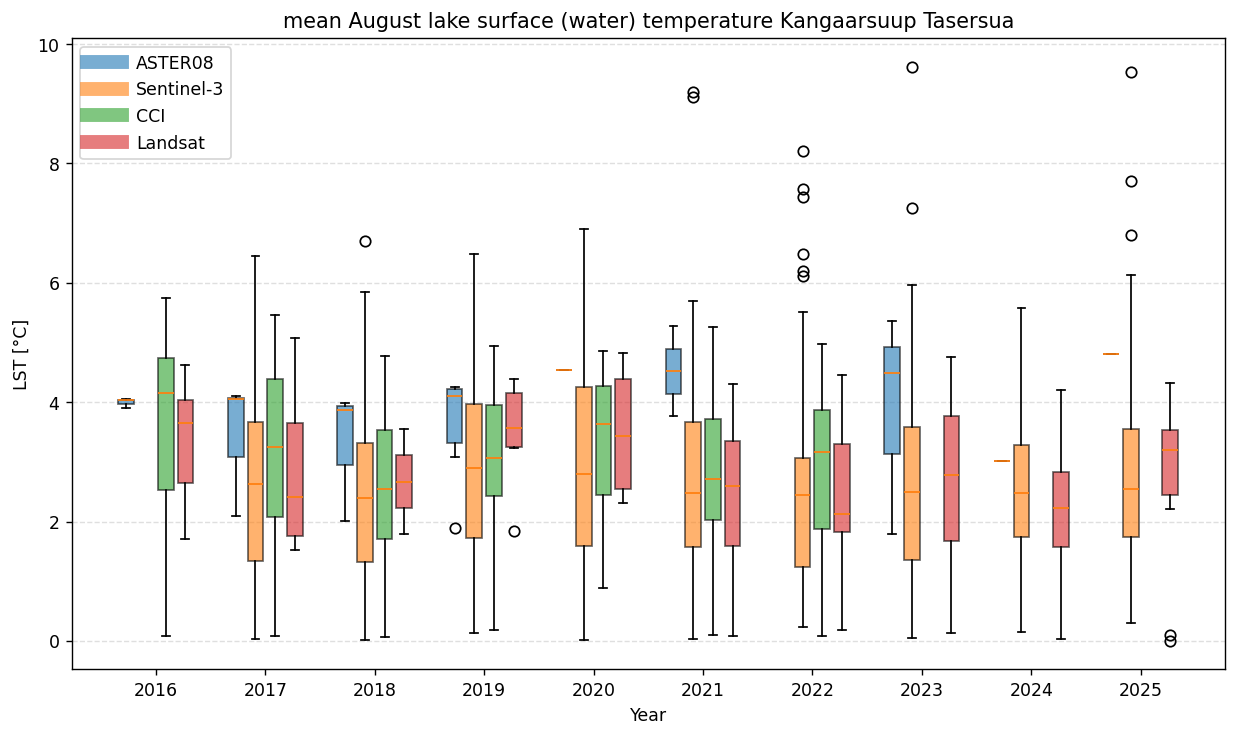

In [18]:
# convert to dt
daily_summary['date'] = pd.to_datetime(
    daily_summary['date']
)

# use only the august
daily_aug = daily_summary[
    (daily_summary['date'].dt.month == 8) | (daily_summary['date'].dt.month == 8)
].copy()

# filter for years from 2016
daily_aug = daily_summary[
    (daily_summary['date'].dt.year > 2015)].copy()

# get the year
daily_aug['year'] = daily_aug['date'].dt.year

# sensor/dataset names
sensor_columns = [
    'ASTER08_lst_mean_C',
    'S3_lst_mean_C',
    'CCIlst_mean_C',
    'LS_ST']

sensor_labels = [
    'ASTER08',
    'Sentinel-3',
    'CCI',
    'Landsat']

# colors for the sensors/data set
sensor_colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red']

# start the figure here
fig, ax = plt.subplots(
    figsize=(10, 6))

years = sorted(
    daily_aug['year'].dropna().unique())

width = 0.18

# position offsets so boxes sit next to each other
offsets = (
    np.arange(len(sensor_columns))
    - (len(sensor_columns) - 1) / 2)


# Create boxplots here

for i, (sensor, label, color) in enumerate(
    zip(sensor_columns, sensor_labels, sensor_colors)
):

    #data for each year
    data = [
        daily_aug.loc[
            daily_aug['year'] == year,
            sensor
        ].dropna()
        for year in years
    ]

    #location of each box
    positions = (
        np.array(years)
        + offsets[i] * width
    )

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width * 0.8,
        patch_artist=True
    )

    #color of the boxes
    for box in bp['boxes']:
        box.set_facecolor(color)
        box.set_alpha(0.6)

    #point for legend
    ax.plot(
        [],
        [],
        color=color,
        linewidth=8,
        alpha=0.6,
        label=label
    )

ax.set_xlabel("Year")
ax.set_ylabel("LST [°C]")

ax.set_xticks(years)
ax.set_xticklabels(years)

ax.set_title(
    "mean August lake surface (water) temperature Kangaarsuup Tasersua"
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

ax.legend()

plt.tight_layout()

path = r"plots/lake_6_August_all_years.pdf"
plt.savefig(path, format="pdf", bbox_inches="tight")


plt.show()

# extend the analysis to other large ice-marginal lakes in Greenland

This now applies the filtering (fraction <45%, temperatures between 0 and 12 dgC) to all lakes and combines them in one dataframe with their respective lake id. It essentially uses the code from above, looping through the different lake datasets that have been saved to csv files in by the script `S3_data_preparation.ipynb` in folder `Sentinel_3_LST`. 

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Folder containing the lake CSV files
data_folder = Path(
    r"Sentinel_3_LST\data_processed"
)

# Find all S3 lake files
lake_files = sorted(data_folder.glob("S3_LST_L2_lake_*.csv"))

print(f"Found {len(lake_files)} lake files:")
for file in lake_files:
    print(file.name)


# Store processed lakes here
all_lakes = []


for file in lake_files:

    # Extract lake number from filename
    # e.g. S3_LST_L2_lake6.csv -> lake6
    lake_name = file.stem.split("_")[-1]

    print(f"Processing {lake_name}")

    # Read data
    S3 = pd.read_csv(file)

    # Convert datetime
    S3["datetime"] = pd.to_datetime(S3["datetime"])

    # Rename S3 columns
    S3 = S3.rename(columns={
        col: f"S3_{col}" 
        for col in S3.columns 
        if col != "datetime"
    })

    # Calculate fraction of maximum valid pixel count
    S3["S3_frac_from_max_pixel_count"] = (
        S3["S3_n_valid_pixels"] /
        S3["S3_n_valid_pixels"].max()
    )

    # --------------------------------------------------
    # FILTERS
    # --------------------------------------------------

    # Positive mean temperature
    S3_filter = S3[
        S3["S3_lst_mean_C"] > 0
    ]

    # Maximum mean temperature
    S3_filter = S3_filter[
        S3_filter["S3_lst_mean_C"] < 12
    ]

    # Positive median temperature
    S3_filter = S3_filter[
        S3_filter["S3_lst_median_C"] > 0
    ]

    # Maximum median temperature
    S3_filter = S3_filter[
        S3_filter["S3_lst_median_C"] < 12
    ]

    # Date range
    S3_filter = S3_filter[
        S3_filter["datetime"].between(
            "2016-01-01",
            "2026-01-01"
        )
    ]

    # Minimum 45% data availability
    S3_filter = S3_filter[
        S3_filter["S3_frac_from_max_pixel_count"] > 0.45
    ]

    # Add lake identifier
    S3_filter["lake"] = lake_name

    # Store
    all_lakes.append(S3_filter)


# Combine all lakes
all_lakes_S3 = pd.concat(
    all_lakes,
    ignore_index=True
)

Found 8 lake files:
S3_LST_L2_lake_1.csv
S3_LST_L2_lake_2.csv
S3_LST_L2_lake_3.csv
S3_LST_L2_lake_4.csv
S3_LST_L2_lake_6.csv
S3_LST_L2_lake_7.csv
S3_LST_L2_lake_8.csv
S3_LST_L2_lake_9.csv
Processing 1
Processing 2
Processing 3
Processing 4
Processing 6
Processing 7
Processing 8
Processing 9


# initial plots of all filtered data points
This creates a time series plot of the filtered data, one plot per lake all together in a pdf file, saved to the plots folder. This is the filtered, but otherwise raw data, no mean calculated or so, as done for the next plot. 

In [20]:
# select only those lakes with a good time series

selected_lakes = [ '6', '7', '8', '9']

In [21]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import pandas as pd

# Select lakes
lakes = all_lakes_S3.lake.unique()
lakes = lakes[lakes.isin(['6', '7', '8', '9'])]

df = all_lakes_S3.copy()
df["datetime"] = pd.to_datetime(df["datetime"])

# Same axes for all lakes
xmin = df["datetime"].min()
xmax = df["datetime"].max()

ymin = df["S3_lst_mean_C"].min()
ymax = df["S3_lst_mean_C"].max()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

path = "plots/all_lakes_S3_points.pdf"

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(13, 9),
    sharex=True,
    sharey=True
)

for i, lake in enumerate(lakes):

    lake_df = df[df["lake"] == lake]
    ax = axes[i]

    ax.set_axisbelow(True)
    ax.grid(True, alpha=0.3)

    ax.scatter(
        lake_df["datetime"],
        lake_df["S3_lst_mean_C"],
        marker=".",
        alpha=0.3,
        color=colors[i % len(colors)]
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_ylabel("LST [°C]")
    ax.set_title(f"Lake {lake} — Sentinel-3 LST L2")

# Only label the bottom x-axis
axes[-1].set_xlabel("Date")

plt.tight_layout()

with PdfPages(path) as pdf:
    pdf.savefig(fig, bbox_inches="tight")

plt.close(fig)

print(f"Saved to: {path}")

Saved to: plots/all_lakes_S3_points.pdf


### plot all lakes (monthly mean)
To get a better overview of the data, summarise the data by monthly means, so that I can plot all lakes in one plot.
Then use a linear mixed effects model with a random effect for lake, aand a fixed effect for month (to take out the seasonal variation) and the variable year to test whether there would be a cooling or warming overall trend across all lakes. 

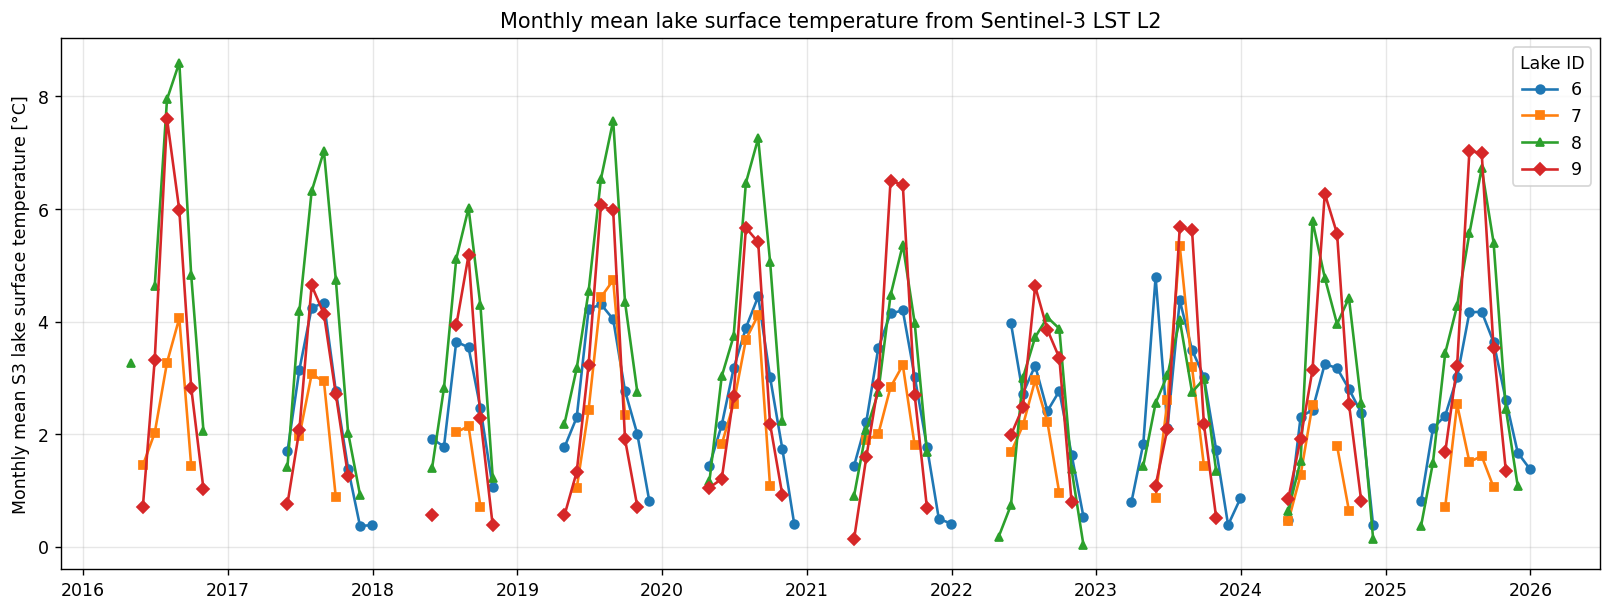

In [22]:
#lakes = all_lakes_S3.lake.unique()

# default colors
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
markers = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]

df = all_lakes_S3.copy()
df["datetime"] = pd.to_datetime(df["datetime"])

monthly = (
    df
    .set_index("datetime")
    .groupby("lake")["S3_lst_mean_C"]
    .resample("ME")
    .mean()
    .reset_index()
)


fig, ax = plt.subplots(figsize=(13, 5))

ax.set_axisbelow(True)
ax.grid(True, alpha=0.3)

for i, lake in enumerate(lakes):

    lake_monthly = monthly[
        monthly["lake"] == lake
    ]

    ax.plot(
        lake_monthly["datetime"],
        lake_monthly["S3_lst_mean_C"],
        marker=markers[i % len(markers)], 
        markersize=5,
        linewidth=1.5,
        color=colors[i % len(colors)],
        label=lake
    )

ax.set_ylabel("Monthly mean S3 lake surface temperature [°C]")
ax.set_xlabel("")

ax.legend(title="Lake ID")

ax.set_title(
    "Monthly mean lake surface temperature from Sentinel-3 LST L2"
)

plt.tight_layout()

path = "plots/all_lakes_monthly_mean.pdf"
plt.savefig(path, format="pdf", bbox_inches="tight")

plt.show()

## check for trend in lake LST from S3 from 4 lakes
Use of a linear model to check for trends in the LST of S3. Create the month grouping variable first. The interaction term (year*C(lake)) expends to + year + year:lake, and estimates the slope for each lake seperately (relative to the first reference lake, as then given in the summary).  

Note: this uses only lake_id 6, 7, 8, 9, since for oters not enough data / large gaps have been in the data. 

In [23]:
# allowing for different slope estimates for eahc lake:

selected = all_lakes_S3[all_lakes_S3["lake"].isin(selected_lakes)] # use only 6, 7, 8 as defined in selected lakes
print(selected.head())

# create monthly variable
# create month variable
monthly_data = selected.copy()
monthly_data["datetime"] = pd.to_datetime(monthly_data["datetime"])

# make month var
monthly_data["month"] = monthly_data.datetime.dt.month

monthly_data["year"] = monthly_data.datetime.dt.year

import statsmodels.formula.api as smf

model_int_year_lake = smf.ols(
    "S3_lst_mean_C ~ year + C(month) + year * C(lake)",
    data=monthly_data
)

result_int = model_int_year_lake.fit()

print(result_int.summary())

                datetime  S3_lst_median_C  S3_lst_mean_C  \
9979 2017-05-06 14:08:00         0.267999       0.774969   
9980 2017-05-07 13:42:00         0.631006       2.075450   
9981 2017-05-12 14:53:00         0.100000       0.103199   
9982 2017-05-15 13:35:00         0.252008       1.229804   
9983 2017-05-21 14:20:00         0.618997       1.583264   

      S3_lst_mean_uncertainty  S3_lst_std  S3_bootstrap_ci_lower  \
9979                 0.177856    1.348044                    NaN   
9980                 0.178347    2.485792                    NaN   
9981                 0.178737    2.342941                    NaN   
9982                 0.177570    2.609498                    NaN   
9983                 0.178184    2.284684                    NaN   

      S3_bootstrap_ci_upper  S3_n_valid_pixels  S3_frac_from_max_pixel_count  \
9979                    NaN                 97                      0.989796   
9980                    NaN                 98                      1.

### get the slope values per lake
Since the model summary returns the slope values relative to the first reference lake (alphanumerically first), one needs to caalculate the slopes first for each lake in order to interpret them. This is done in the next chunk of code.

In [24]:

# calculate the slope values for each lake (reference year 1 + lake_specific slope parameter estimate)
#lake1 = result_int.params["year"]
#lake3 = result_int.params["year"]+result_int.params["year:C(lake)[T.3]"]
#lake4 = result_int.params["year"]+result_int.params["year:C(lake)[T.4]"]
lake6 = result_int.params["year"]#+result_int.params["year:C(lake)[T.6]"]
lake7 = result_int.params["year"]+result_int.params["year:C(lake)[T.7]"]
lake8 = result_int.params["year"]+result_int.params["year:C(lake)[T.8]"]
lake9 = result_int.params["year"]+result_int.params["year:C(lake)[T.9]"]

#print(f"slope lake 1: {lake1}")
#print(f"slope lake 3: {lake3}")
#print(f"slope lake 4: {lake4}")
print(f"slope lake 6: {lake6}")
print(f"slope lake 7: {lake7}")
print(f"slope lake 8: {lake8}")
print(f"slope lake 9: {lake9}")



slope lake 6: 0.06806260220134167
slope lake 7: 0.008385908952868289
slope lake 8: -0.13754948255591776
slope lake 9: 0.05409365431486694


### visualise the slope estimates per lake

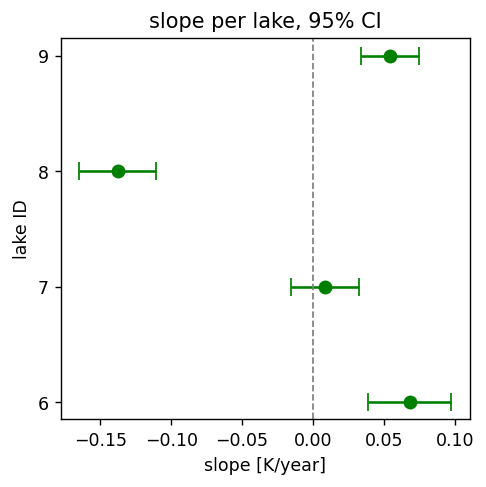

In [25]:
#lake specific slopes
lakes = [1, 3, 4, 6, 7, 8, 9]

# select only 6, 7, 8, 9
lakes = [6, 7, 8, 9]


slopes = []
ci_lower = []
ci_upper = []

for lake in lakes:
    # Main year effect
    slope = result_int.params["year"]

    # Add lake-specific interaction, except for reference lake 1
    if lake != 6:
        interaction = f"year:C(lake)[T.{lake}]"
        slope += result_int.params[interaction]

    # Calculate SE of the combined slope
    if lake == 6:
        var = result_int.cov_params().loc["year", "year"]
    else:
        interaction = f"year:C(lake)[T.{lake}]"
        cov = result_int.cov_params()

        var = (
            cov.loc["year", "year"]
            + cov.loc[interaction, interaction]
            + 2 * cov.loc["year", interaction]
        )

    se = np.sqrt(var)

    # 95% CI
    lower = slope - 1.96 * se
    upper = slope + 1.96 * se

    slopes.append(slope)
    ci_lower.append(lower)
    ci_upper.append(upper)

# Convert CIs to error-bar distances
errors = [
    np.array(slopes) - np.array(ci_lower),
    np.array(ci_upper) - np.array(slopes)
]

# Plot
fig, ax = plt.subplots(figsize=(4, 4))

ax.errorbar(
    slopes,
    lakes,
    xerr=errors,
    fmt="o",
    capsize=5,
    markersize=7, 
    color = "green"
)

# Reference line at slope = 0
ax.axvline(0, linestyle="--", linewidth=1, color = "grey")

ax.set_xlabel("slope [K/year]")
ax.set_ylabel("lake ID")
ax.set_title("slope per lake, 95% CI")

ax.set_yticks(lakes)

path = r"plots/slopes_all_lakes_S3.pdf"
plt.savefig(path, format="pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()